# Google Colab Lab Assignment -NLP

**Course Name:** Deep Learning

**Lab Title:** NLP Techniques for Text Classification

**Student Name:** Manjiri Netankar

**Student ID:** 202201040206

**Date of Submission:** [06/04/2025]

**Group Members**: Sapna Dahikamble
                   Supriya Maskar


**Objective**
The objective of this assignment is to implement NLP preprocessing techniques and build a text classification model using machine learning techniques.




**Learning Outcomes:**

1. Understand and apply NLP preprocessing techniques such as tokenization, stopword removal, stemming, and lemmatization.

2. Implement text vectorization techniques such as TF-IDF and CountVectorizer.

3. Develop a text classification model using a machine learning algorithm.

4. Evaluate the performance of the model using suitable metrics.

# **Assignment Instructions:**

**Part 1: NLP Preprocessing**

**Dataset Selection:**

Choose any text dataset from **Best Datasets for Text** https://en.innovatiana.com/post/best-datasets-for-text-classification Classification, such as SMS Spam Collection, IMDb Reviews, or any other relevant dataset.

Download the dataset and upload it to Google Colab.

Load the dataset into a Pandas DataFrame and explore its structure (e.g., check missing values, data types, and label distribution).

Text Preprocessing:

Convert text to lowercase.

Perform tokenization using NLTK or spaCy.

Remove stopwords using NLTK or spaCy.

Apply stemming using PorterStemmer or SnowballStemmer.

Apply lemmatization using WordNetLemmatizer.

Vectorization Techniques:

Convert text data into numerical format using TF-IDF and CountVectorizer.



In [ ]:
#Code for Part 1
# Step 1: Import Libraries
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS

# Step 2: Load the dataset
df = pd.read_csv("/content/sample_data/IMDB Dataset.csv")

# Step 3: Explore the dataset
print("Dataset Info:\n", df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nLabel Distribution:\n", df['sentiment'].value_counts())

# Step 4: Text Preprocessing Function
def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and numbers
    tokens = text.split()  # Tokenize (split by space)
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]  # Remove stopwords
    return ' '.join(tokens)

# Step 5: Apply preprocessing (use a sample if full dataset is too large)
df_sample = df.head(1000).copy()
df_sample['cleaned_review'] = df_sample['review'].apply(preprocess_text)

# Step 6: Vectorization - CountVectorizer
count_vectorizer = CountVectorizer(max_features=1000)
X_count = count_vectorizer.fit_transform(df_sample['cleaned_review'])

# Step 7: Vectorization - TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df_sample['cleaned_review'])

# Step 8: Output Vector Shapes and Sample Features
print("\nCountVectorizer Shape:", X_count.shape)
print("CountVectorizer Features (first 10):", count_vectorizer.get_feature_names_out()[:10])

print("\nTF-IDF Shape:", X_tfidf.shape)
print("TF-IDF Features (first 10):", tfidf_vectorizer.get_feature_names_out()[:10])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
Dataset Info:
 None

Missing Values:
 review       0
sentiment    0
dtype: int64

Label Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64

CountVectorizer Shape: (1000, 1000)
CountVectorizer Features (first 10): ['ability' 'able' 'absolutely' 'accent' 'act' 'acted' 'acting' 'action'
 'actor' 'actors']

TF-IDF Shape: (1000, 1000)
TF-IDF Features (first 10): ['ability' 'able' 'absolutely' 'accent' 'act' 'acted' 'acting' 'action'
 'actor' 'actors']


**Splitting the Data:**

Divide the dataset into training and testing sets (e.g., 80% training, 20% testing).

**Building the Classification Model:**

Train a text classification model using Logistic Regression, Naïve Bayes, or any other suitable algorithm.

Implement the model using scikit-learn.

**Model Evaluation:**

Evaluate the model using accuracy, precision, recall, and F1-score.

Use a confusion matrix to visualize the results.


📊 Evaluation for Logistic Regression
Accuracy: 0.835
Precision: 0.8118811881188119
Recall: 0.8541666666666666
F1 Score: 0.8324873096446701

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       104
           1       0.81      0.85      0.83        96

    accuracy                           0.83       200
   macro avg       0.84      0.84      0.83       200
weighted avg       0.84      0.83      0.84       200



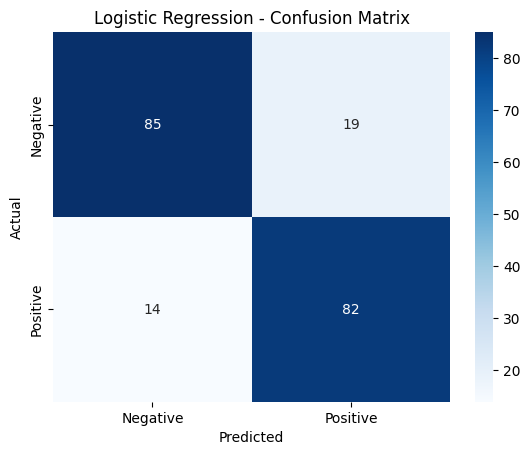


📊 Evaluation for Naive Bayes
Accuracy: 0.82
Precision: 0.8191489361702128
Recall: 0.8020833333333334
F1 Score: 0.8105263157894737

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       104
           1       0.82      0.80      0.81        96

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



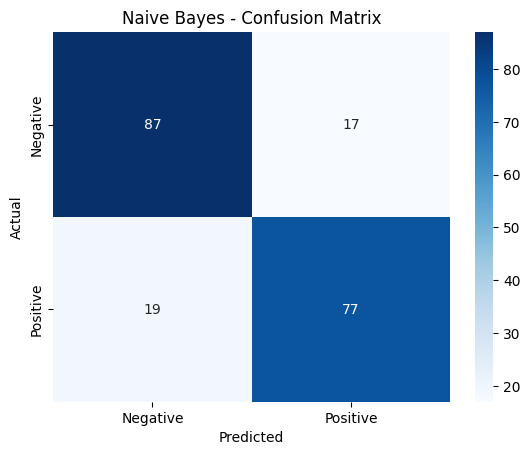

In [ ]:
#code for Part 2
# Step 9: Import ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 10: Label Encoding (positive = 1, negative = 0)
df_sample['label'] = df_sample['sentiment'].map({'positive': 1, 'negative': 0})

# Step 11: Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df_sample['label'], test_size=0.2, random_state=42
)

# Step 12: Train a Model - Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Step 13: Train a Model - Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Step 14: Evaluation Function
def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"\n📊 Evaluation for {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Step 15: Evaluate Both Models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")


**Submission Guidelines:**

**Google Colab Notebook Submission:**

Save your notebook as NLP_Text_Classification_YourName.ipynb.

Ensure all code cells are executed, and the output is visible.

Include proper documentation and comments explaining each step.

**Report Submission (Optional):**

Prepare a short report (2-3 pages) summarizing your approach, findings, and model performance.

Upload the report along with the Colab Notebook.



**Grading Criteria:**

Correct implementation of NLP preprocessing (30%)

Effective use of vectorization techniques (20%)

Model accuracy and performance evaluation (30%)

Code clarity, documentation, and presentation (20%)

**Declaration**

I, [Your Name], confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: [Full Name]

**Submission Checklist**

✔ Ultralitycs Platform Documentsation Like hel file for Given Task

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Evaluation Metrics Details and discussion